This notebook tests the output of the transcript-based segmentation tool Proseg for imaging-based spatial trasncriptomics data. 

Xenium data for SN222R1-Ma1Fd2-1U1 has been processed with Proseg, and this notebook demonstrates the UMAP and clustering results before and after Proseg.

We use spatialdata environment to read in the sample from the default Xenium output and the Proseg-corrected version.

We then use GPU-acceleration (rapids-singlecell) to speed up normalization, HVG selection, PCA, UMAP, and clustering.

In [52]:
import scanpy as sc
import spatialdata as sd
import spatialdata_io as sdio
import rapids_singlecell as rsc
import cupyx as cpx
import matplotlib.pyplot as plt
import os
# Specify the GPU index you want to use (e.g., "1", "2", or "3")
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

/data/chouw/Software/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/data/chouw/Software/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
/data/chouw/Software/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.memb

In [54]:
# Define standard processing steps
def xenium_processing(adata):
    rsc.get.anndata_to_GPU(adata)
    rsc.pp.filter_cells(adata, min_counts = 5)
    rsc.pp.normalize_total(adata)
    rsc.pp.log1p(adata)
    rsc.pp.highly_variable_genes(adata, flavor="seurat_v3")
    rsc.pp.pca(adata, n_comps = 30)
    rsc.pp.neighbors(adata, n_pcs = 30, n_neighbors = 30, metric = "cosine", random_state = 42)
    rsc.tl.umap(adata, min_dist = 0.3, random_state = 42)
    rsc.tl.leiden(adata, resolution = 0.8, random_state = 42)
    return adata



In [58]:
all_markers = {
    "HSC": ["CD34", "AVP", "SPINK2", "SMIM24"],
    "Erythroblast": ["PCNA", "MYC", "CENPF"],  # "PARP1", "GATA1", 
    "LateErythroid": ["AHSP", "ALAS2", "SLC4A1", "HEMGN"],
    "Megakaryocyte": ["PF4", "PLEK", "CAVIN2", "MMRN1"],
    "GMP": ["ELANE", "MPO", "CTSG", "FUT4"],
    "LateMyeloid": ["LTF", "CAMP", "RETN"],
    "Neutrophil": ["MMP9", "AQP9", "IL1R2", "S100A12"],  # "ITGAM", 
    "BaEoMast": ["GATA2", "MS4A2", "CPA3"],  # "MS4A3", 
    "CD14Monocyte": ["VCAN", "FCN1", "CD14"],
    "Macrophage": ["CD5L", "CD163", "VSIG4"],
    "pDC": ["IRF8", "RUNX2", "LILRA4", "IL3RA"],
    "cDC2": ["CLEC10A", "CD1C", "FCER1A"],
    "CD4T": ["CD3D", "CD3E", "TRAC", "IL7R", "CD4", "CCL5"],
    "CD8T": ["CD8A", "NKG7"],
    "NKcell": ["GNLY", "CD247", "PRF1", "KLRD1"],
    "EarlyB": ["DNTT"],  # "IGLL1", "VPREB1"
    "MatureB": ["TCL1A", "MS4A1", "CD79A", "CD19", "BANK1"],
    "Plasma": ["MZB1", "SDC1", "SLAMF7", "TNFRSF17"],
    "MSC": ["LEPR", "CXCL12", "FBN1", "ALDH1A3"],
    "Adipocyte": ["FABP4", "PLIN4", "ADIPOQ", "LPL"],
    "Osteoblastic": ["SPP1", "BGLAP", "SFRP4", "CTSK"],
    "AEC": ["BTNL9"],
    "SEC": ["DNASE1L3"],
    "Endothelial": ["KDR", "FLT4", "PECAM1"],  # "ENG"
    "vSMC": ["ACTA2", "MYH11", "PDGFRB"]
}

## Original Xenium data (default Xenium segmentation)

In [53]:
sn222 = sdio.xenium("SN222R1-Ma1Fd2-1U1_Xenium_Output")

/data/chouw/tmp/ipykernel_254408/2956837048.py:1: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sn222 = sdio.xenium("SN222R1-Ma1Fd2-1U1_Xenium_Output")
/data/chouw/Software/miniforge3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [55]:
xe_adata = sn222['table'].copy()

# Filter out snv probes
probes_to_keep = [x for x in xe_adata.var_names if '_WT' not in x and '_ALT' not in x]
xe_adata = xe_adata[:, probes_to_keep].copy()
xe_adata = xenium_processing(xe_adata)
#xe_adata.write_h5ad('SN222_original.h5ad')

filtered out 4969 cells that have less than 5 counts


/data/chouw/Software/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/rapids_singlecell/preprocessing/_hvg.py:534: UserWarning: `flavor='seurat_v3'` expects `n_top_genes`  to be defined, defaulting to 2000 HVGs
  warnings.warn(
/data/chouw/Software/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/rapids_singlecell/preprocessing/_hvg.py:549: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


... storing 'feature_types' as categorical
... storing 'genome' as categorical


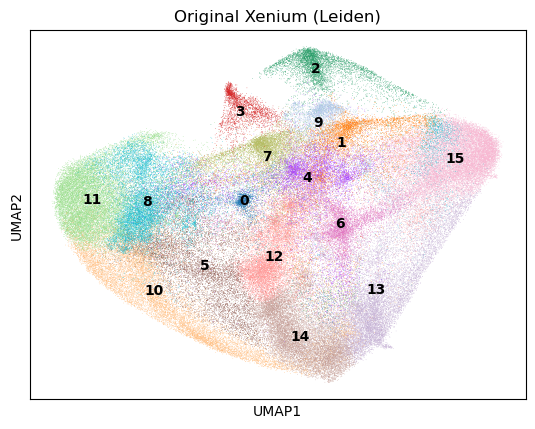

In [56]:
sc.pl.umap(xe_adata, color = 'leiden', legend_loc = 'on data', title = 'Original Xenium (Leiden)')

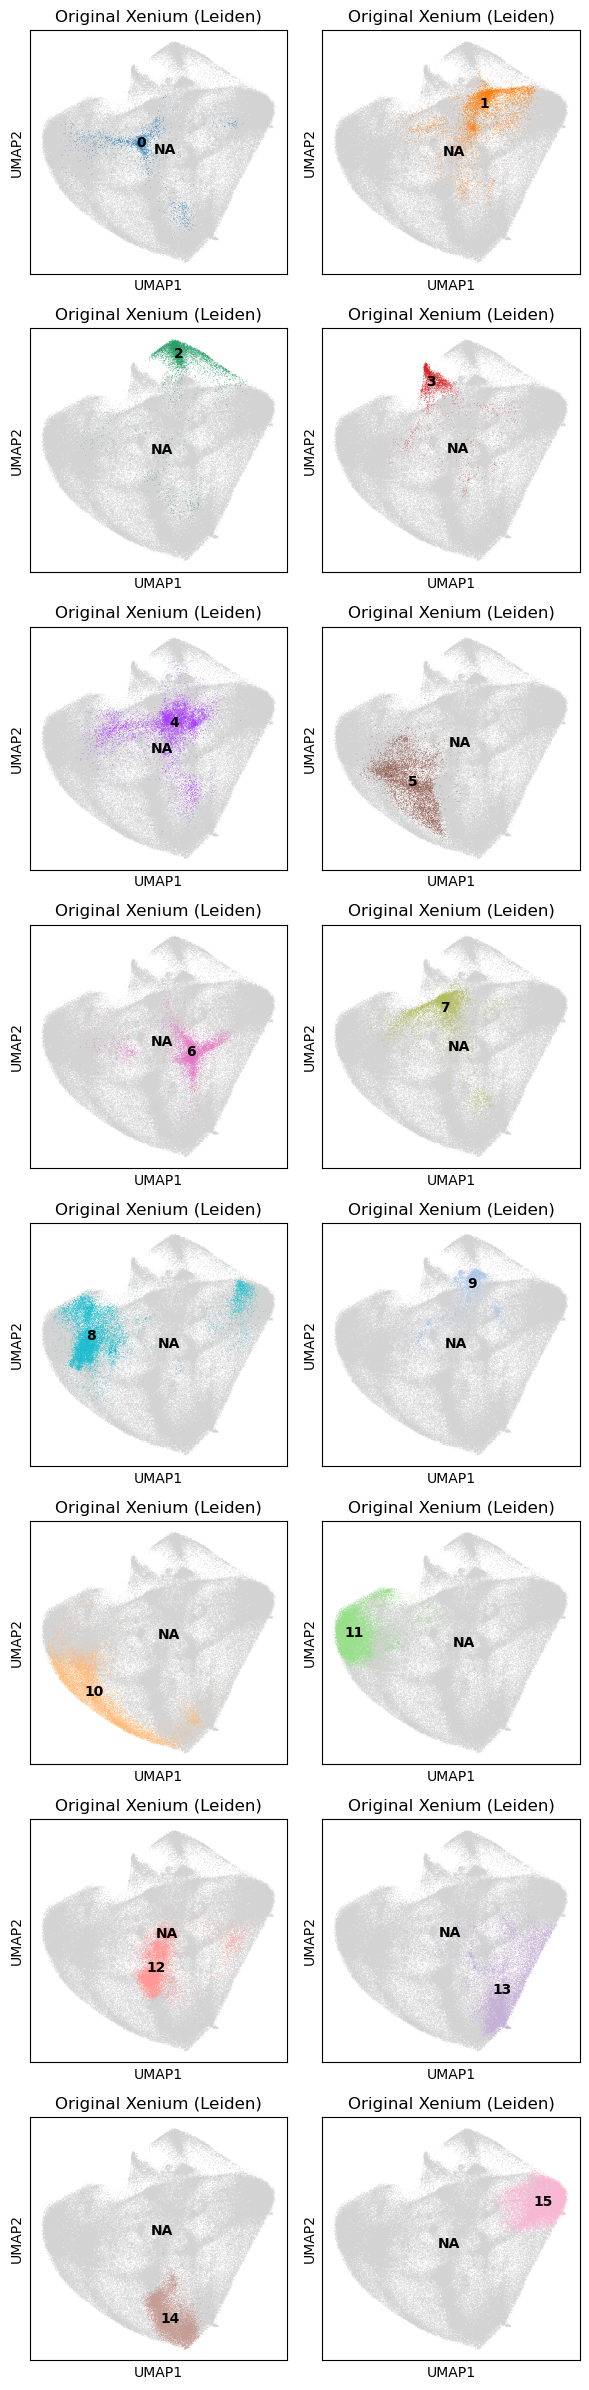

In [57]:
num_plots = len(xe_adata.obs['leiden'].unique())
fig, axs = plt.subplots(int(num_plots/2), 2, figsize = (6, int(num_plots/2) * 3))
for i in sorted(xe_adata.obs['leiden'].unique()):
    sc.pl.umap(xe_adata, color = 'leiden', legend_loc = 'on data', groups = i, ax = axs[int(i)//2, int(i)%2], title = 'Original Xenium (Leiden)', show = False)
plt.tight_layout()
plt.savefig('xenium_umap_by_cluster.png', dpi = 300)
plt.show()

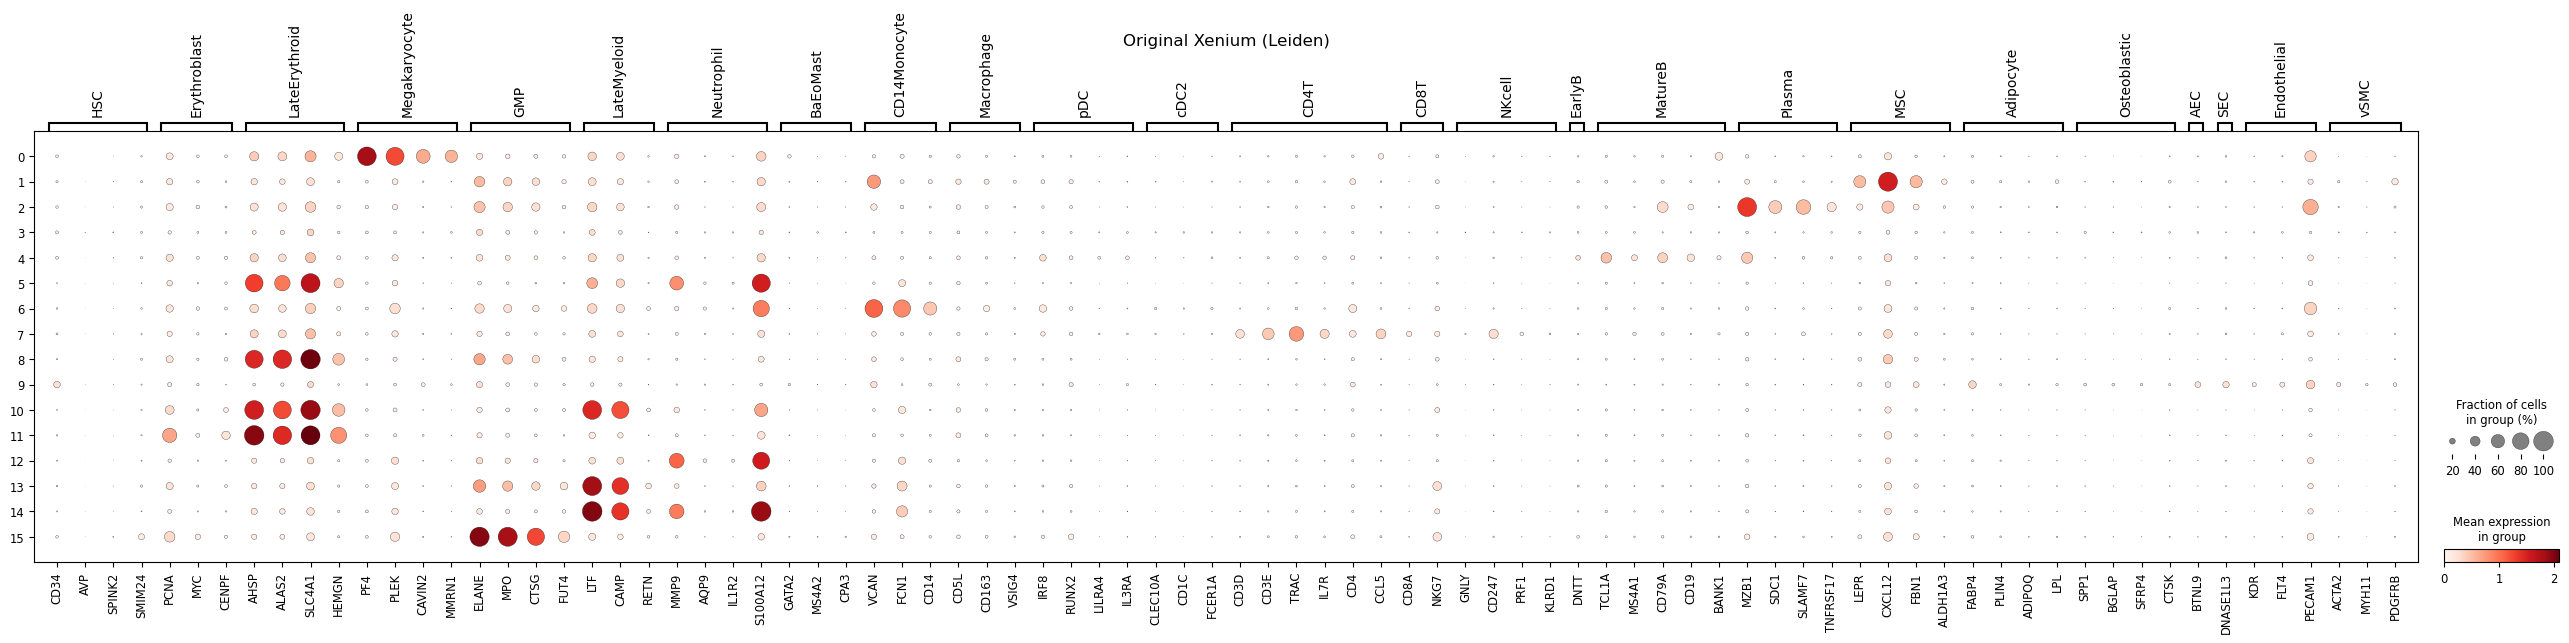

In [59]:
rsc.get.anndata_to_CPU(xe_adata)
sc.pl.dotplot(xe_adata, all_markers, groupby='leiden', title = 'Original Xenium (Leiden)', save = 'xenium_dotplot_by_cluster.png')
plt.show()

## SN222R1 processed by Proseg

In [60]:
sdata = sd.read_zarr('proseg-output.zarr')

/data/chouw/tmp/ipykernel_254408/2701398943.py:1: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr('proseg-output.zarr')


In [61]:
proseg_adata = sdata['table'].copy()

# Filter out snv probes
probes_to_keep = [x for x in proseg_adata.var_names if '_WT' not in x and '_ALT' not in x]
proseg_adata = proseg_adata[:, probes_to_keep].copy()
proseg_adata.X = proseg_adata.X.astype('float32')
proseg_adata = xenium_processing(proseg_adata)
#proseg_adata.write_h5ad('SN222_proseg.h5ad')


filtered out 8316 cells that have less than 5 counts


/data/chouw/Software/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/rapids_singlecell/preprocessing/_hvg.py:534: UserWarning: `flavor='seurat_v3'` expects `n_top_genes`  to be defined, defaulting to 2000 HVGs
  warnings.warn(
/data/chouw/Software/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/rapids_singlecell/preprocessing/_hvg.py:549: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


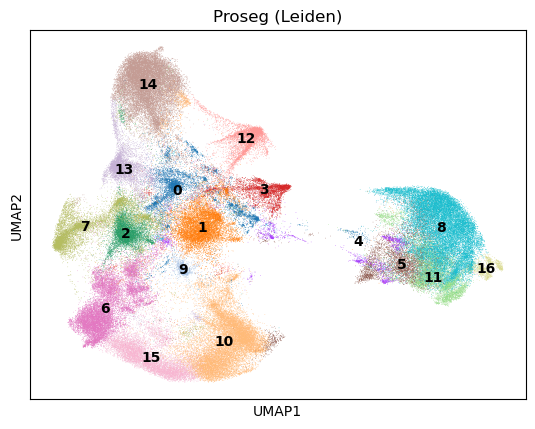

In [63]:
sc.pl.umap(proseg_adata, color = 'leiden', legend_loc = 'on data', title = 'Proseg (Leiden)')

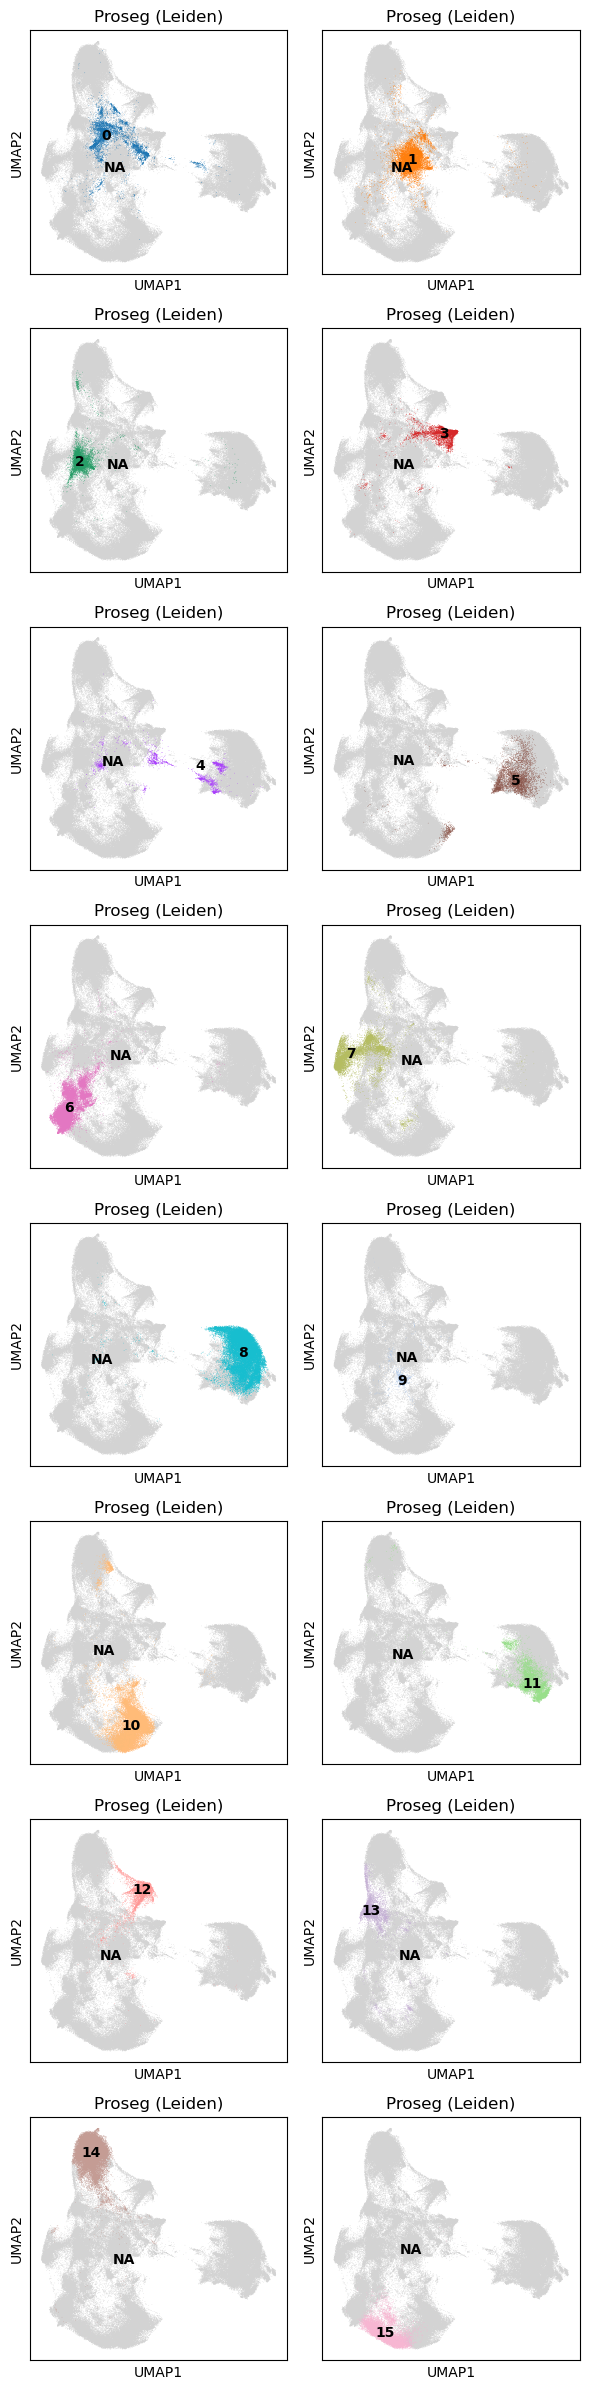

In [64]:
num_plots = len(xe_adata.obs['leiden'].unique())
fig, axs = plt.subplots(int(num_plots/2), 2, figsize = (6, int(num_plots/2) * 3))
for i in sorted(xe_adata.obs['leiden'].unique()):
    sc.pl.umap(proseg_adata, color = 'leiden', legend_loc = 'on data', groups = i, ax = axs[int(i)//2, int(i)%2], title = 'Proseg (Leiden)', show = False)
plt.tight_layout()
plt.savefig('proseg_umap_by_cluster.png', dpi = 300)
plt.show()

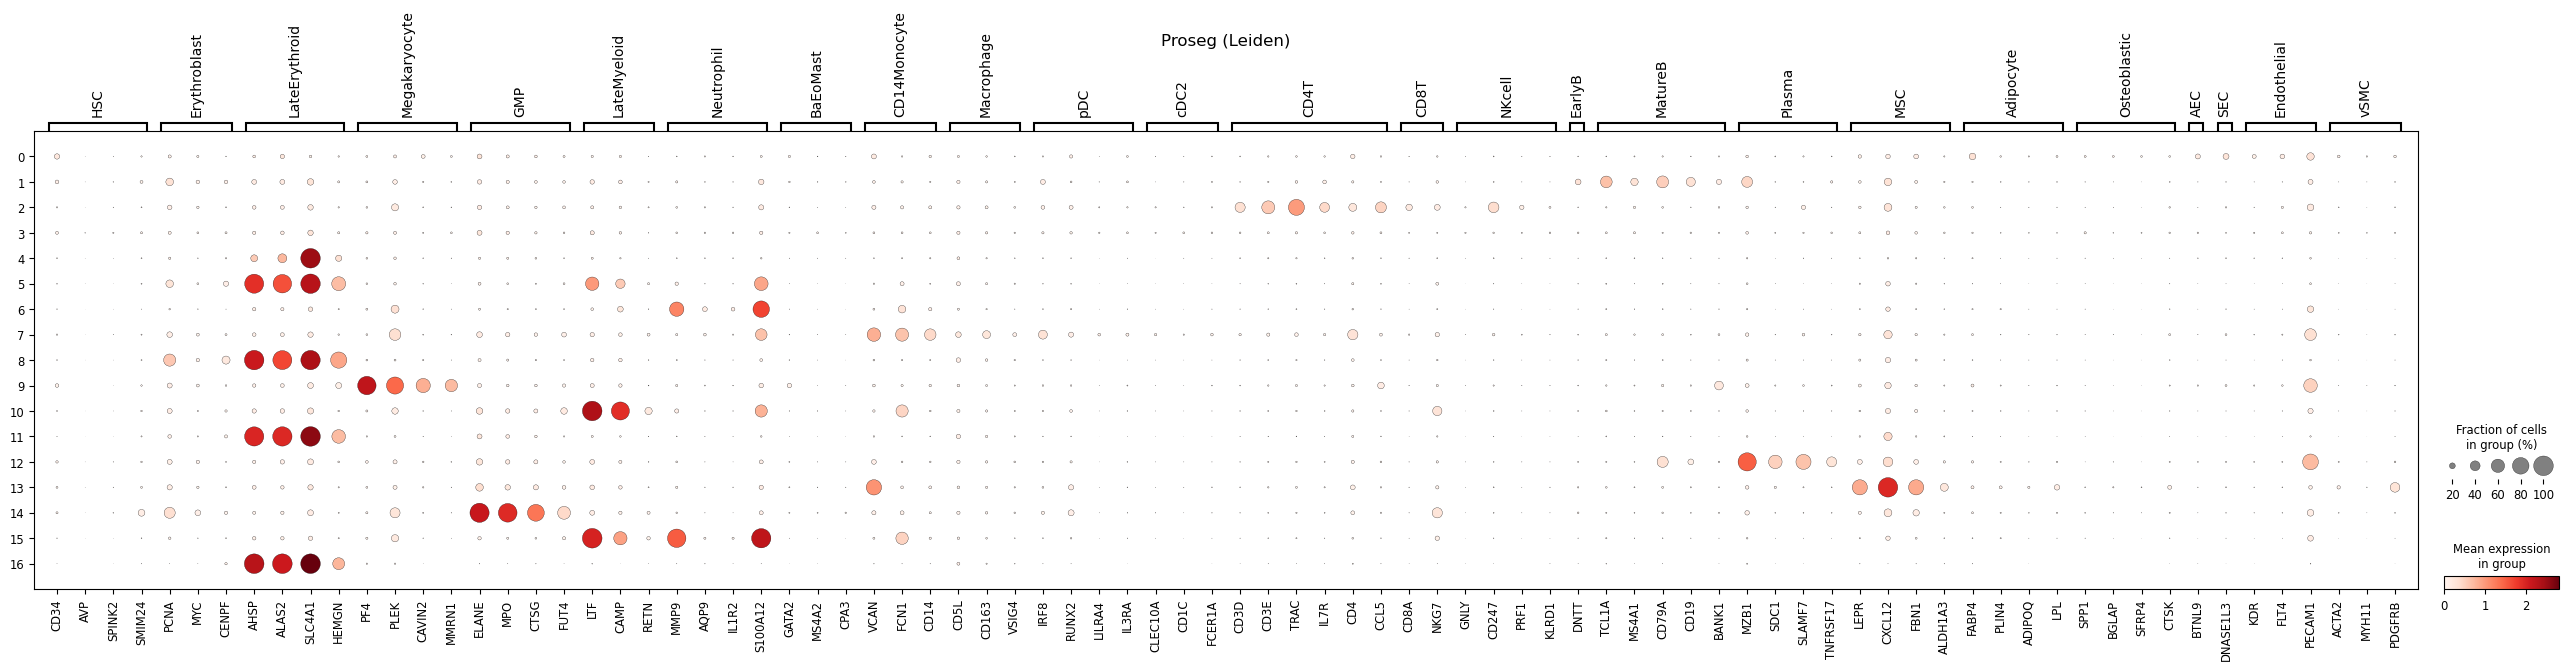

In [65]:
rsc.get.anndata_to_CPU(proseg_adata)
sc.pl.dotplot(proseg_adata, all_markers, groupby='leiden', title = 'Proseg (Leiden)', save = 'proseg_dotplot_by_cluster.png')
plt.show()
